In [5]:
%load_ext autoreload
%autoreload 2

import time
import jax
import jax.numpy as jnp
from jaxmarl.environments import CoopForagingFixedOther, CoopForaging
from jax_tqdm import scan_tqdm
from jaxmarl.environments.toy_coop.coop_foraging_fixed_other import leader_action, follower_action
from jaxmarl.viz.toy_coop_jitted_visualizer import render_fn
import matplotlib.pyplot as plt
import imageio
import numpy as np

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Benchmark env steps/s as a function of # of parallel envs

Testing with 1 parallel environments...


Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 18302.95it/s]


Steps per second (SPS): 3205.4124479709462
Testing with 10 parallel environments...


Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 17005.77it/s]


Steps per second (SPS): 30583.022257124492
Testing with 100 parallel environments...


...

Steps per second (SPS): 293156.0814942053
Testing with 1000 parallel environments...


Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 18106.99it/s]


Steps per second (SPS): 2880838.088664004
Testing with 10000 parallel environments...


Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 18012.90it/s]


Steps per second (SPS): 29349893.714991186


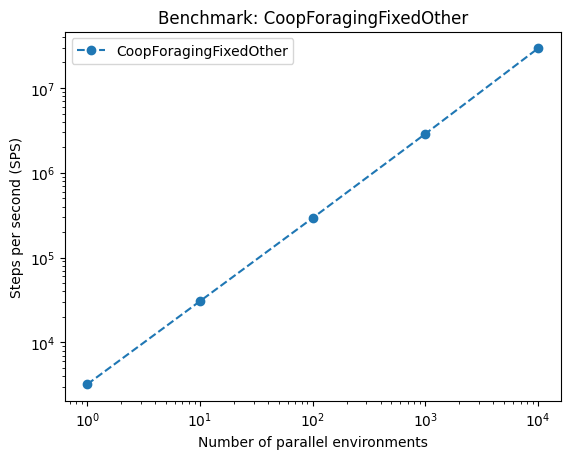

In [6]:
# Define the configuration for the benchmark
config = {
    "NUM_STEPS": 1000,  # Number of steps per environment
    "NUM_ENVS": 100,  # Number of parallel environments
    "ENV_KWARGS": {
        "max_steps": 100,
        "random_reset": True,
        "debug": False,
        "check_held_out": False,
        "partial_obs": False,
        "incentivize_strat": 2,
        "size": 8,
    },
    "SEED": 0,
}

def gen_heldout(env):
    @scan_tqdm(100)
    def gen_held_out_toycoop(runner_state, unused):
        (i,) = runner_state
        key = jax.random.key(i)
        state = env.custom_reset_fn(key, random_reset=True)
        res = (state.agent_pos, state.goal_pos, state.other_goal_pos)
        carry = (i+1,)
        return carry, res
    
    carry, res = jax.lax.scan(gen_held_out_toycoop, (0,), jnp.arange(100), 100)
    ho_agent_pos, ho_goal_pos, ho_other_goal_pos = res
    
    # Set the held-out states in the environment
    env.held_out_agent_pos = ho_agent_pos
    env.held_out_goal_pos = ho_goal_pos
    env.held_out_other_goal_pos = ho_other_goal_pos
    return env

# Create the CoopForagingFixedOther environment
def make_env():
    return CoopForagingFixedOther(**config["ENV_KWARGS"])

# Benchmark function
def benchmark(env, num_envs, num_steps):
    def step_fn(carry, _):
        state, rng = carry
        rng, step_rng = jax.random.split(rng)
        # step_rngs = jax.random.split(step_rng, num_envs)

        # Random actions for the trainable agent
        # actions = jax.random.randint(step_rngs, (num_envs,), 0, env.action_space.n)
        rng, _rng = jax.random.split(rng)
        num_actors = num_envs * env.num_agents
        rngs = jax.random.split(_rng, num_actors).reshape((env.num_agents, num_envs, -1))
        actions = {k: jax.vmap(env.action_space(k).sample)(rngs[i]) for i, k in enumerate(env.agents)}
        rng, _rng = jax.random.split(rng)
        rng_step = jax.random.split(_rng, num_envs)

        obs, state, rewards, dones, infos = jax.vmap(env.step)(rng_step, state, actions)
        return (state, rng), None

    rng = jax.random.PRNGKey(config["SEED"])
    rng, reset_rng = jax.random.split(rng)
    reset_rngs = jax.random.split(reset_rng, num_envs)

    # Reset the environment
    obs, state = jax.vmap(env.reset)(reset_rngs)

    # Run the benchmark
    rng, step_rng = jax.random.split(rng)
    before = time.perf_counter()
    jax.lax.scan(step_fn, (state, step_rng), None, length=num_steps)
    after = time.perf_counter()

    total_time = after - before
    sps = num_envs * num_steps / total_time
    return sps

# Test the environment with different numbers of parallel environments
num_envs_list = [1, 10, 100, 1000, 10000]
sps_results = []

for num_envs in num_envs_list:
    print(f"Testing with {num_envs} parallel environments...")
    env = make_env()
    env = gen_heldout(env)
    sps = benchmark(env, num_envs, config["NUM_STEPS"])
    sps_results.append(sps)
    print(f"Steps per second (SPS): {sps}")

# Plot the results
import matplotlib.pyplot as plt

plt.plot(num_envs_list, sps_results, linestyle="--", marker="o", label="CoopForagingFixedOther")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of parallel environments")
plt.ylabel("Steps per second (SPS)")
plt.title("Benchmark: CoopForagingFixedOther")
plt.legend()
plt.show()

### Sanity test: compare random policy with mirror policy (lead if other agent is following)

Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 18455.16it/s]


Evaluating random policy...
Average return (random policy): -96.22000122070312
Evaluating mirroring policy...
Average return (mirroring policy): 180.76998901367188


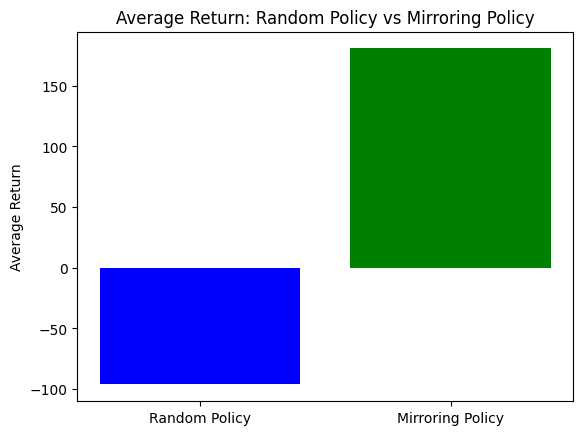

In [7]:
from jaxmarl.environments.toy_coop.coop_foraging_fixed_other import leader_action, follower_action


# Evaluate average return for random policy vs mirroring policy
def evaluate_policy(env, num_envs, num_steps, policy_fn):
    """
    Evaluate a given policy in the environment.

    Args:
        env: The environment to evaluate.
        num_envs: Number of parallel environments.
        num_steps: Number of steps to run the evaluation.
        policy_fn: A function that takes (obs, state) and returns actions.

    Returns:
        Average return across all environments.
    """
    rng = jax.random.PRNGKey(config["SEED"])
    rng, reset_rng = jax.random.split(rng)
    reset_rngs = jax.random.split(reset_rng, num_envs)

    # Reset the environment
    obs, state = jax.vmap(env.reset)(reset_rngs)

    def step_fn(carry, _):
        obs, state, rng, total_rewards = carry
        rng, step_rng = jax.random.split(rng)

        # Get actions from the policy
        actions = policy_fn(obs, state, step_rng)

        # Step the environment
        rng_step = jax.random.split(step_rng, num_envs)
        next_obs, next_state, rewards, dones, infos = jax.vmap(env.step)(rng_step, state, actions)

        # Accumulate rewards
        total_rewards += rewards["agent_0"]  # Assuming we're only interested in the trainable agent's rewards

        # Reset environments where done
        reset_rngs = jax.random.split(step_rng, num_envs)
        next_obs, next_state = jax.lax.cond(
            dones["agent_0"].any(),
            lambda _: jax.vmap(env.reset)(reset_rngs),
            lambda _: (next_obs, next_state),
            operand=None
        )

        return (next_obs, next_state, rng, total_rewards), None

    # Run the evaluation
    total_rewards = jnp.zeros(num_envs)
    (obs, state, _, total_rewards), _ = jax.lax.scan(step_fn, (obs, state, rng, total_rewards), None, length=num_steps)

    # Compute average return
    avg_return = total_rewards.mean()
    return avg_return

# Define the random policy
def random_policy(obs, state, rng):
    rng, action_rng = jax.random.split(rng)
    return {"agent_0": jax.random.randint(action_rng, (obs["agent_0"].shape[0],), 0, env.num_actions)}

# Define the mirroring policy
def mirroring_policy(obs, state, rng):
    def mirror_action(state):
        # If the fixed agent is a leader, the trainable agent becomes a follower, and vice versa
        fixed_agent_type = state.other_agent_type

        # Use jax.lax.cond for JAX-compatible control flow
        return jax.lax.cond(
            (fixed_agent_type == 0) | (fixed_agent_type == 1),  # Condition: fixed agent is a leader
            lambda _: follower_action(state, agent_idx=0),     # True branch: trainable agent becomes a follower
            lambda _: leader_action(state, goal_idx=0, agent_idx=0),  # False branch: trainable agent becomes a leader
            operand=None
        )

    return {"agent_0": jax.vmap(mirror_action)(state)}

# Run the evaluation
num_envs = 100
num_steps = 100

env = make_env()
env = gen_heldout(env)

print("Evaluating random policy...")
random_policy_return = evaluate_policy(env, num_envs, num_steps, random_policy)
print(f"Average return (random policy): {random_policy_return}")

print("Evaluating mirroring policy...")
mirroring_policy_return = evaluate_policy(env, num_envs, num_steps, mirroring_policy)
print(f"Average return (mirroring policy): {mirroring_policy_return}")

# Plot the results
policies = ["Random Policy", "Mirroring Policy"]
returns = [random_policy_return, mirroring_policy_return]

plt.bar(policies, returns, color=["blue", "green"])
plt.ylabel("Average Return")
plt.title("Average Return: Random Policy vs Mirroring Policy")
plt.show()

### Visualize leader/follower pair dynamics in the environment, or leader/leader, or follower/follwer. 

In [8]:


# Visualize an episode of leader/follower agents
def run_episode(env, num_steps, agent_0_func, agent_1_func):
    """
    Visualize an episode of a pair of leader/follower agents in the CoopForagingFixedOther environment.

    Args:
        env: The environment to visualize.
        num_steps: Number of steps in the episode.
        leader_idx: Index of the leader agent.
        follower_idx: Index of the follower agent.
    """
    rng = jax.random.PRNGKey(1)
    rng, reset_rng = jax.random.split(rng)

    # Reset the environment
    obs, state = env.reset(reset_rng)

    # Initialize frames for visualization
    frames = []

    # Run the episode
    for t in range(num_steps):
        # Leader and follower actions

        actions = {
            "agent_0": agent_0_func(state),
            "agent_1": agent_1_func(state),
        }

        # Step the environment
        rng, step_rng = jax.random.split(rng)
        obs, state, rewards, dones, infos = env.step(step_rng, state, actions)
        # Render the environment
        img = render_fn(state, size=env.height)

        # Convert the rendered image to a format suitable for saving
        frames.append(np.array(img))

    return frames



def make_coop_env():
    return CoopForaging(**config["ENV_KWARGS"])


def gen_coop_heldout(env):
    @scan_tqdm(100)
    def gen_held_out_toycoop(runner_state, unused):
        (i,) = runner_state
        key = jax.random.key(i)
        state = env.custom_reset_fn(key, random_reset=True)
        res = (state.agent_pos, state.goal_pos, state.other_goal_pos)
        carry = (i+1,)
        return carry, res
    
    carry, res = jax.lax.scan(gen_held_out_toycoop, (0,), jnp.arange(100), 100)
    ho_agent_pos, ho_goal_pos, ho_other_goal_pos = res
    
    # Set the held-out states in the environment
    env.held_out_agent_pos = ho_agent_pos
    env.held_out_goal_pos = ho_goal_pos
    env.held_out_other_goal_pos = ho_other_goal_pos
    return env


In [9]:
# Create the environment
env = make_coop_env()
env = gen_coop_heldout(env)
agent_0_func = lambda s: leader_action(s, goal_idx=0, agent_idx=0)
agent_1_func = lambda s: follower_action(s, agent_idx=1)
# Visualize an episode
frames = run_episode(env, num_steps=50, agent_0_func=agent_0_func, agent_1_func=agent_1_func)
# Save the episode as a GIF
gif_path = "../visualizations/leader_follower_episode.gif"
imageio.mimsave(gif_path, frames, fps=5)
print(f"Saved episode visualization to {gif_path}")

Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 17871.68it/s]


Saved episode visualization to ../visualizations/leader_follower_episode.gif


In [10]:
# Create the environment
env = make_coop_env()
env = gen_coop_heldout(env)
agent_0_func = lambda s: leader_action(s, goal_idx=0, agent_idx=0)
agent_1_func = lambda s: leader_action(s, goal_idx=1, agent_idx=1)
# Visualize an episode
frames = run_episode(env, num_steps=50, agent_0_func=agent_0_func, agent_1_func=agent_1_func)
# Save the episode as a GIF
gif_path = "../visualizations/leader_leader_episode.gif"
imageio.mimsave(gif_path, frames, fps=5)
print(f"Saved episode visualization to {gif_path}")

Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 17954.30it/s]


Saved episode visualization to ../visualizations/leader_leader_episode.gif


In [11]:
# Create the environment
env = make_coop_env()
env = gen_coop_heldout(env)
agent_0_func = lambda s: follower_action(s, agent_idx=0)
agent_1_func = lambda s: follower_action(s, agent_idx=1)
# Visualize an episode
frames = run_episode(env, num_steps=50, agent_0_func=agent_0_func, agent_1_func=agent_1_func)
# Save the episode as a GIF
gif_path = "../visualizations/follower_follower_episode.gif"
imageio.mimsave(gif_path, frames, fps=5)
print(f"Saved episode visualization to {gif_path}")

Running for 100 iterations: 100%|██████████| 100/100 [00:00<00:00, 17844.31it/s]


Saved episode visualization to ../visualizations/follower_follower_episode.gif
